In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.spatial.distance import euclidean
import sounddevice as sd
from scipy.io.wavfile import write
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
def record_audio(duration=2, sample_rate=44100):
  
    print(f"Recording for {duration} seconds...")
    audio_data = sd.rec(int(duration * sample_rate), 
                        samplerate=sample_rate, 
                        channels=1, 
                        dtype='float64')
    sd.wait()
    print("Recording complete!")
    return audio_data.flatten(), sample_rate


def save_audio(filename, audio_data, sample_rate):
    """Save audio data to WAV file"""
    write(filename, sample_rate, audio_data)
    print(f"Audio saved to {filename}")

In [7]:
# Record Signal 1 (Your voice)
print("\n=== Recording Signal 1 (Your Voice) ===")
print("Say 'hello' when recording starts...")
signal1, sr1 = record_audio(duration=2, sample_rate=44100)
save_audio("signal1_your_voice.wav", signal1, sr1)

# Record Signal 2 (Friend's voice)
print("\n=== Recording Signal 2 (Friend's Voice) ===")
print("Ask your friend to say 'hello' when recording starts...")
signal2, sr2 = record_audio(duration=2, sample_rate=44100)
save_audio("signal2_friend_voice.wav", signal2, sr2)

print("\nBoth recordings completed!")


=== Recording Signal 1 (Your Voice) ===
Say 'hello' when recording starts...
Recording for 2 seconds...
Recording complete!
Audio saved to signal1_your_voice.wav

=== Recording Signal 2 (Friend's Voice) ===
Ask your friend to say 'hello' when recording starts...
Recording for 2 seconds...
Recording complete!
Audio saved to signal2_friend_voice.wav

Both recordings completed!


In [8]:
def load_audio(filename):
    sample_rate, data = wavfile.read(filename)
    # Convert to mono if stereo
    if len(data.shape) > 1:
        data = data.mean(axis=1)
    return data, sample_rate


# Load the recorded signals
signal1, sr1 = load_audio("signal1_your_voice.wav")
signal2, sr2 = load_audio("signal2_friend_voice.wav")

print(f"Signal 1 shape: {signal1.shape}, Sample rate: {sr1} Hz")
print(f"Signal 2 shape: {signal2.shape}, Sample rate: {sr2} Hz")

Signal 1 shape: (88200,), Sample rate: 44100 Hz
Signal 2 shape: (88200,), Sample rate: 44100 Hz


In [9]:
def normalize_signal(signal):

    signal = signal.astype(float)
    max_val = np.max(np.abs(signal))
    if max_val > 0:
        return signal / max_val
    return signal


# Normalize both signals
signal1_norm = normalize_signal(signal1)
signal2_norm = normalize_signal(signal2)

print("Signals normalized successfully!")
print(f"Signal 1 range: [{signal1_norm.min():.3f}, {signal1_norm.max():.3f}]")
print(f"Signal 2 range: [{signal2_norm.min():.3f}, {signal2_norm.max():.3f}]")

Signals normalized successfully!
Signal 1 range: [-1.000, 0.974]
Signal 2 range: [-1.000, 0.798]


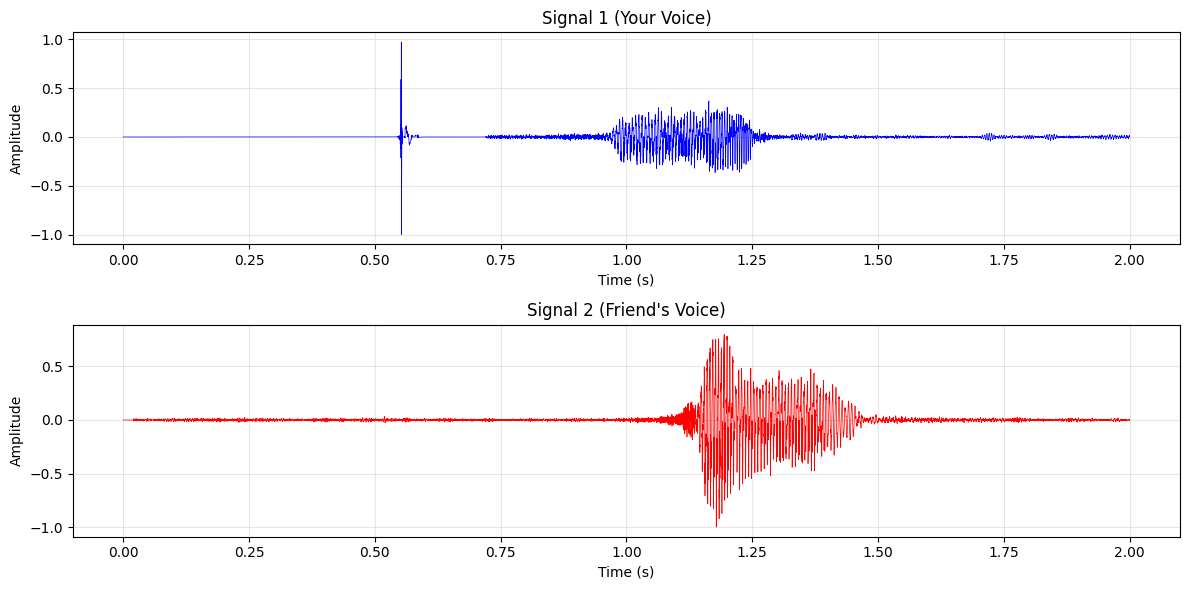

In [10]:
def plot_signals(signal1, signal2, sr1, sr2, title="Audio Signals"):
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    
    time1 = np.arange(len(signal1)) / sr1
    time2 = np.arange(len(signal2)) / sr2
    
    axes[0].plot(time1, signal1, color='blue', linewidth=0.5)
    axes[0].set_title('Signal 1 (Your Voice)')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(time2, signal2, color='red', linewidth=0.5)
    axes[1].set_title('Signal 2 (Friend\'s Voice)')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Amplitude')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('normalized_signals.png', dpi=300, bbox_inches='tight')
    plt.show()


plot_signals(signal1_norm, signal2_norm, sr1, sr2, "Normalized Audio Signals")

In [11]:
def dtw_distance(s1, s2, window=None):
    
    n, m = len(s1), len(s2)
    
    # Initialize cost matrix with infinity
    cost_matrix = np.full((n + 1, m + 1), np.inf)
    cost_matrix[0, 0] = 0
    
    # Fill the cost matrix
    for i in range(1, n + 1):
        # Apply window constraint if specified
        if window is not None:
            start = max(1, i - window)
            end = min(m + 1, i + window + 1)
        else:
            start, end = 1, m + 1
        
        for j in range(start, end):
            cost = abs(s1[i-1] - s2[j-1])
            cost_matrix[i, j] = cost + min(
                cost_matrix[i-1, j],    # insertion
                cost_matrix[i, j-1],    # deletion
                cost_matrix[i-1, j-1]   # match
            )
    
    # Backtrack to find optimal path
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i-1, j-1))
        
        # Choose the direction with minimum cost
        candidates = [
            (i-1, j-1, cost_matrix[i-1, j-1]),
            (i-1, j, cost_matrix[i-1, j]),
            (i, j-1, cost_matrix[i, j-1])
        ]
        i, j, _ = min(candidates, key=lambda x: x[2])
    
    path.reverse()
    
    return cost_matrix[n, m], cost_matrix[1:, 1:], path


In [12]:
def downsample_signal(signal, factor=100):
    
    n = len(signal)
    new_length = n // factor
    downsampled = np.array([signal[i*factor:(i+1)*factor].mean() 
                           for i in range(new_length)])
    return downsampled


# Downsample signals for faster DTW computation
downsample_factor = 100
s1_down = downsample_signal(signal1_norm, downsample_factor)
s2_down = downsample_signal(signal2_norm, downsample_factor)

print(f"Downsampled Signal 1: {len(s1_down)} samples")
print(f"Downsampled Signal 2: {len(s2_down)} samples")

Downsampled Signal 1: 882 samples
Downsampled Signal 2: 882 samples


In [13]:
print("\nApplying Dynamic Time Warping...")
dtw_dist, cost_matrix, alignment_path = dtw_distance(s1_down, s2_down)

print(f"\n=== DTW Results ===")
print(f"DTW Distance: {dtw_dist:.4f}")
print(f"Number of alignment points: {len(alignment_path)}")
print(f"Cost matrix shape: {cost_matrix.shape}")


Applying Dynamic Time Warping...

=== DTW Results ===
DTW Distance: 14.9516
Number of alignment points: 1306
Cost matrix shape: (882, 882)


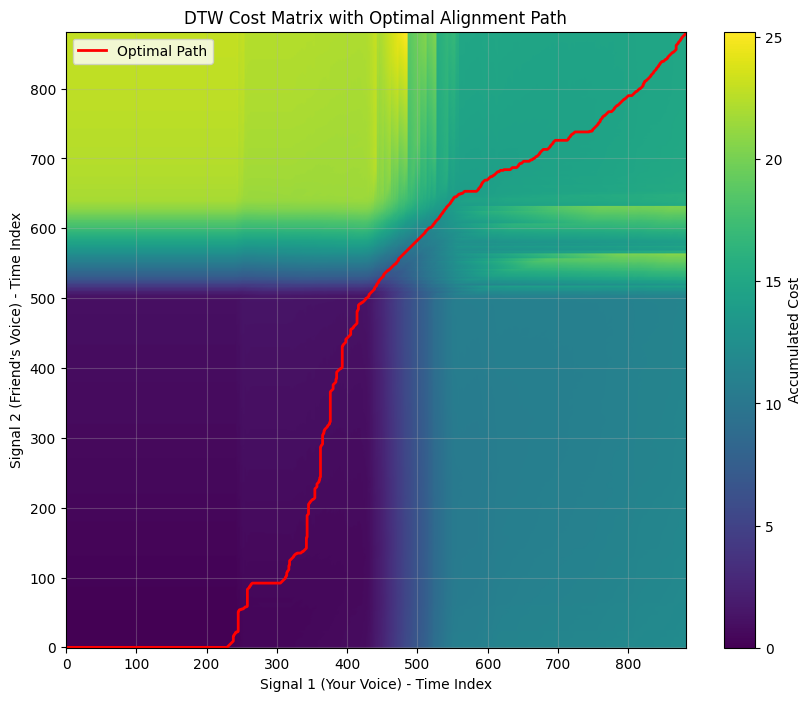

In [14]:
def plot_cost_matrix(cost_matrix, path):

    plt.figure(figsize=(10, 8))
    plt.imshow(cost_matrix.T, origin='lower', cmap='viridis', aspect='auto')
    plt.colorbar(label='Accumulated Cost')
    
    # Plot the optimal path
    path_x = [p[0] for p in path]
    path_y = [p[1] for p in path]
    plt.plot(path_x, path_y, color='red', linewidth=2, label='Optimal Path')
    
    plt.xlabel('Signal 1 (Your Voice) - Time Index')
    plt.ylabel('Signal 2 (Friend\'s Voice) - Time Index')
    plt.title('DTW Cost Matrix with Optimal Alignment Path')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('dtw_cost_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()


plot_cost_matrix(cost_matrix, alignment_path)